<html>
  <body>
    <header></header>
        <CENTER>
          <img src="https://professor.uvv.br/Content/img/logo-uvv.png" alt="UVV-LOGO" style = width="100px"; height="100px">
        </CENTER>
        <CENTER><b>DATA SCIENCE PROJECT</b></CENTER><br/>
        <CENTER><b>WORKFLOW 2 DO PROJETO</b></CENTER><br/>

**NOME: Isabela Carone Lacerda**


# **BIBLIOTECAS**

In [1]:
# stdlib
import os
import warnings

# terceiros
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

SEED = 42
np.random.seed(SEED)


# **FUNÇÕES: FAZER TODAS AS ATIVIDADES MODULARIZADAS (def) AQUI:**

In [2]:
# ============================================================
# ETAPA 0 — calculo do tamanho ideal (JA FEITO no WORKFLOW PARTE 1)
# ============================================================
# Conforme conclusao da Parte 1: n* = 1.900 (ponto de intersecao
# da curva SE(n) com a faixa de +/-5 % em torno de SE_final).
N_IDEAL = 1_900

def _resolver_dataset(nome: str = "table16.csv") -> str:
    """Procura ``data/<nome>`` no diretorio atual e ate 3 niveis acima."""
    base = os.path.abspath(os.getcwd())
    for _ in range(4):
        candidato = os.path.join(base, "data", nome)
        if os.path.isfile(candidato):
            return candidato
        base = os.path.dirname(base)
    raise FileNotFoundError(
        f"Nao encontrei data/{nome} a partir de {os.getcwd()}")

CAMINHO_DADOS = _resolver_dataset()
TAMANHO_CHUNK = 200_000
TARGET = "TOTAL (R$)"
COLUNAS_DESCARTADAS = ["NOTA FISCAL", "OPINIÃO DO CLIENTE"]
COLUNAS_CATEGORICAS = ["REGIÃO", "SEXO", "ESTADO CIVIL", "TIPO DA CONTA"]


def carregar_dataset_limpo(caminho: str = CAMINHO_DADOS) -> pd.DataFrame:
    """Reproduz a limpeza do WORKFLOW PARTE 1 sobre o dataset.

    Etapas (na ordem):
      1. Leitura em chunks com downcast de tipos.
      2. Drop de NOTA FISCAL e OPINIAO DO CLIENTE.
      3. Remocao de duplicatas e NaN.
      4. Remocao de outliers do TARGET pelo metodo IQR (1.5 x IQR).
    """
    pedacos: list[pd.DataFrame] = []
    for pedaco in pd.read_csv(caminho, index_col=0, chunksize=TAMANHO_CHUNK):
        for col in pedaco.select_dtypes(include="float").columns:
            pedaco[col] = pd.to_numeric(pedaco[col], downcast="float")
        for col in pedaco.select_dtypes(include="integer").columns:
            pedaco[col] = pd.to_numeric(pedaco[col], downcast="integer")
        for col in COLUNAS_CATEGORICAS + ["OPINIÃO DO CLIENTE"]:
            if col in pedaco.columns:
                pedaco[col] = pedaco[col].astype("category")
        pedacos.append(pedaco)
    df = pd.concat(pedacos, ignore_index=True)

    # drop colunas + duplicatas + nulos
    df = df.drop(columns=COLUNAS_DESCARTADAS, errors="ignore")
    df = df.drop_duplicates().dropna().reset_index(drop=True)

    # outliers IQR sobre o target
    q1, q3 = df[TARGET].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = df[TARGET].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
    df = df.loc[mask].reset_index(drop=True)

    print(f"Dataset limpo carregado: {len(df):,} linhas x {df.shape[1]} colunas.")
    return df


In [3]:
# ============================================================
# ETAPA 1 — gerar SAMPLE 1 e SAMPLE 2 (mesmo tamanho ideal)
# ============================================================
def atividade_1_1(df: pd.DataFrame,
                  n_ideal: int = N_IDEAL,
                  seed: int = SEED) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Sorteia duas amostras INDEPENDENTES de tamanho n_ideal.

    Para garantir independencia, amostra sem reposicao no dataset inteiro
    de tamanho 2 * n_ideal e em seguida divide em sample1 / sample2.
    """
    if len(df) < 2 * n_ideal:
        raise ValueError("Dataset menor que 2 * n_ideal — nao da pra dividir.")
    sorteio = df.sample(n=2 * n_ideal, random_state=seed).reset_index(drop=True)
    sample1 = sorteio.iloc[:n_ideal].reset_index(drop=True)
    sample2 = sorteio.iloc[n_ideal:].reset_index(drop=True)
    print(f"sample1: {sample1.shape}  sample2: {sample2.shape}")
    return sample1, sample2


In [4]:
# ============================================================
# ETAPA 2 — testes em UMA amostra (AD test + ANOVA Bootstrap)
# ============================================================
def teste_anderson_darling(amostra: pd.Series, nome: str = "amostra") -> dict:
    """Teste de normalidade de Anderson-Darling sobre uma serie numerica.

    Usa ``method="interpolate"`` explicitamente (compatibilidade com
    SciPy >= 1.17, onde o parametro passa a ser obrigatorio).

    Returns:
        dict com estatistica, valores criticos, niveis e veredito a 5 %.
    """
    # Mantemos a interface classica (critical_values / significance_level)
    # — em SciPy >= 1.17 isso emite FutureWarning, suprimido localmente.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", FutureWarning)
        resultado = stats.anderson(amostra.dropna(), dist="norm")
    stat = float(resultado.statistic)
    criticos = resultado.critical_values.tolist()
    niveis = resultado.significance_level.tolist()
    idx_5 = (niveis.index(5.0) if 5.0 in niveis
             else min(range(len(niveis)), key=lambda i: abs(niveis[i] - 5.0)))
    critico_5 = criticos[idx_5]
    veredito = "NAO Normal (rejeita H0)" if stat > critico_5 else "Normal (nao rejeita H0)"

    print(f"\n--- Anderson-Darling : {nome} ---")
    print(f"  Estatistica A2     : {stat:.4f}")
    print(f"  Niveis (%)         : {niveis}")
    print(f"  Valores criticos   : {criticos}")
    print(f"  Critico a 5 %      : {critico_5:.4f}")
    print(f"  CONCLUSAO (alfa=5%): {veredito}")
    return {"stat": stat, "criticos": criticos, "niveis": niveis,
            "critico_5": critico_5, "veredito": veredito}


def anova_bootstrap_uma_amostra(amostra: pd.DataFrame,
                                target: str = TARGET,
                                grupo: str = "TIPO DA CONTA",
                                n_boot: int = 1_000,
                                seed: int = SEED) -> dict:
    """ANOVA one-way (F-stat) reamostrada via bootstrap dentro de UMA amostra.

    Resampleia ``n_boot`` vezes (com reposicao) preservando o tamanho da
    amostra, aplicando F-test entre as categorias presentes em ``grupo``.

    Returns:
        dict com arrays bootstrap (F_boot, p_boot), estatistica observada,
        % de rejeicao e leitura ``best_fit``.
    """
    rng = np.random.default_rng(seed)
    categorias = list(pd.Series(amostra[grupo]).dropna().unique())

    def _f_stat(df: pd.DataFrame) -> tuple[float, float]:
        grupos = [df.loc[df[grupo] == c, target].to_numpy() for c in categorias]
        grupos = [g for g in grupos if len(g) > 1 and np.std(g) > 0]
        if len(grupos) < 2:
            return float("nan"), float("nan")
        f, p = stats.f_oneway(*grupos)
        return float(f), float(p)

    f_obs, p_obs = _f_stat(amostra)
    f_boot = np.empty(n_boot)
    p_boot = np.empty(n_boot)
    idx_base = np.arange(len(amostra))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        for b in range(n_boot):
            idx = rng.choice(idx_base, size=len(amostra), replace=True)
            f_boot[b], p_boot[b] = _f_stat(amostra.iloc[idx])

    pct_rej = float(np.mean(p_boot <= 0.05) * 100)
    best_fit = ("Diferenca significativa entre os grupos (H0 rejeitada em "
                f"{pct_rej:.1f}% das reamostragens)" if pct_rej >= 95 else
                "Sem evidencia de diferenca robusta entre os grupos "
                f"(H0 rejeitada em apenas {pct_rej:.1f}%)")

    return {"f_obs": f_obs, "p_obs": p_obs,
            "f_boot": f_boot, "p_boot": p_boot,
            "pct_rejeicao": pct_rej, "best_fit": best_fit}


def plotar_anova_bootstrap(resultado: dict, nome: str) -> None:
    """Plota histogramas das distribuicoes bootstrap de F-stat e p-value."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(resultado["f_boot"], bins=40, color="steelblue",
                 edgecolor="black", alpha=0.7)
    axes[0].axvline(resultado["f_obs"], color="red", linestyle="--",
                    label=f"F observado = {resultado['f_obs']:.2f}")
    axes[0].set_title(f"Bootstrap F-stat — {nome}")
    axes[0].set_xlabel("F"); axes[0].legend()

    axes[1].hist(resultado["p_boot"], bins=40, color="salmon",
                 edgecolor="black", alpha=0.7)
    axes[1].axvline(0.05, color="black", linestyle="--", label="alfa = 0.05")
    axes[1].set_title(f"Bootstrap p-value — {nome}")
    axes[1].set_xlabel("p-value"); axes[1].legend()
    plt.tight_layout()
    plt.show()


In [5]:
# ============================================================
# ETAPA 3 — testes em DUAS amostras
# ============================================================
def teste_medias_duas_amostras(a: pd.Series, b: pd.Series,
                               nome_a: str = "SAMPLE 1",
                               nome_b: str = "SAMPLE 2") -> dict:
    """Teste t de Welch para diferenca de medias entre duas amostras."""
    stat_t, p_t = stats.ttest_ind(a.dropna(), b.dropna(), equal_var=False)
    veredito = ("MEDIAS DIFERENTES (rejeita H0)" if p_t <= 0.05
                else "MEDIAS IGUAIS (nao rejeita H0)")
    print(f"\n--- Teste t (Welch) : {nome_a} vs {nome_b} ---")
    print(f"  Media {nome_a:<10}: {a.mean():.4f}")
    print(f"  Media {nome_b:<10}: {b.mean():.4f}")
    print(f"  t = {stat_t:.4f} | p-value = {p_t:.6g}")
    print(f"  CONCLUSAO (alfa=5%): {veredito}")
    return {"stat": float(stat_t), "p": float(p_t), "veredito": veredito}


def bootstrap_diferenca_medias(a: pd.Series, b: pd.Series,
                               n_boot: int = 2_000,
                               seed: int = SEED) -> dict:
    """Distribuicao bootstrap da diferenca de medias (a - b) com IC 95 %."""
    rng = np.random.default_rng(seed)
    arr_a, arr_b = a.dropna().to_numpy(), b.dropna().to_numpy()
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        diffs[i] = (rng.choice(arr_a, size=len(arr_a), replace=True).mean()
                    - rng.choice(arr_b, size=len(arr_b), replace=True).mean())
    ic = np.percentile(diffs, [2.5, 97.5])
    p = float(2 * min(float(np.mean(diffs >= 0)), float(np.mean(diffs <= 0))))
    print(f"\n--- Bootstrap diferenca de medias (B={n_boot}) ---")
    print(f"  Media diferenca : {diffs.mean():+.4f}")
    print(f"  IC 95 %         : [{ic[0]:+.4f}, {ic[1]:+.4f}]")
    print(f"  p-value (vs 0)  : {p:.6g}")
    print(f"  BEST FIT        : "
          f"{'diferenca significativa' if p <= 0.05 else 'sem diferenca significativa'}")
    return {"diffs": diffs, "ic": ic.tolist(), "p": p}


def teste_ks_duas_amostras(a: pd.Series, b: pd.Series,
                           nome_a: str = "SAMPLE 1",
                           nome_b: str = "SAMPLE 2") -> dict:
    """Teste KS de mesma distribuicao entre duas amostras."""
    stat_ks, p_ks = stats.ks_2samp(a.dropna(), b.dropna())
    veredito = ("DISTRIBUICOES DIFERENTES (rejeita H0)" if p_ks <= 0.05
                else "MESMA DISTRIBUICAO (nao rejeita H0)")
    print(f"\n--- KS-test : {nome_a} vs {nome_b} ---")
    print(f"  KS = {stat_ks:.4f} | p-value = {p_ks:.6g}")
    print(f"  CONCLUSAO (alfa=5%): {veredito}")
    return {"stat": float(stat_ks), "p": float(p_ks), "veredito": veredito}


def bootstrap_ks(a: pd.Series, b: pd.Series,
                 n_boot: int = 1_000, seed: int = SEED) -> dict:
    """Distribuicao bootstrap da estatistica KS entre duas amostras."""
    rng = np.random.default_rng(seed)
    arr_a, arr_b = a.dropna().to_numpy(), b.dropna().to_numpy()
    ks_boot = np.empty(n_boot)
    p_boot = np.empty(n_boot)
    for i in range(n_boot):
        ra = rng.choice(arr_a, size=len(arr_a), replace=True)
        rb = rng.choice(arr_b, size=len(arr_b), replace=True)
        ks_boot[i], p_boot[i] = stats.ks_2samp(ra, rb)
    pct_rej = float(np.mean(p_boot <= 0.05) * 100)
    print(f"\n--- Bootstrap KS (B={n_boot}) ---")
    print(f"  KS medio                       : {ks_boot.mean():.4f}")
    print(f"  p-value medio                  : {p_boot.mean():.6g}")
    print(f"  % reamostragens com p <= 0.05  : {pct_rej:.1f}%")
    print(f"  BEST FIT                       : "
          f"{'distribuicoes diferentes' if pct_rej >= 95 else 'mesma distribuicao'}")
    return {"ks_boot": ks_boot, "p_boot": p_boot, "pct_rejeicao": pct_rej}


def teste_independencia_chi2(a: pd.DataFrame, b: pd.DataFrame,
                             var1: str = "REGIÃO",
                             var2: str = "TIPO DA CONTA",
                             nome_a: str = "SAMPLE 1",
                             nome_b: str = "SAMPLE 2") -> dict:
    """Chi-quadrado de independencia entre var1 e var2 em cada amostra."""
    resultados: dict[str, dict] = {}
    for nome, df_amostra in [(nome_a, a), (nome_b, b)]:
        tabela = pd.crosstab(df_amostra[var1], df_amostra[var2])
        chi2, p, dof, _ = stats.chi2_contingency(tabela)
        veredito = ("DEPENDENTES (rejeita H0)" if p <= 0.05
                    else "INDEPENDENTES (nao rejeita H0)")
        print(f"\n--- Chi-quadrado {var1} x {var2} : {nome} ---")
        print(f"  Chi2 = {chi2:.4f} | dof = {dof} | p-value = {p:.6g}")
        print(f"  CONCLUSAO (alfa=5%): {veredito}")
        resultados[nome] = {"chi2": float(chi2), "p": float(p),
                            "dof": int(dof), "veredito": veredito}
    return resultados


def bootstrap_chi2(amostra: pd.DataFrame,
                   var1: str = "REGIÃO",
                   var2: str = "TIPO DA CONTA",
                   n_boot: int = 1_000,
                   seed: int = SEED) -> dict:
    """Distribuicao bootstrap do p-value do Chi-quadrado em uma amostra.

    Reamostragem com reposicao preservando o par (var1, var2) de cada linha:
    mede a *estabilidade* do teste de independencia na amostra. Reamostragens
    degeneradas (tabela com menos de 2 linhas/colunas) sao descartadas.
    """
    rng = np.random.default_rng(seed)
    p_boot = np.empty(n_boot)
    idx_base = np.arange(len(amostra))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        for i in range(n_boot):
            idx = rng.choice(idx_base, size=len(amostra), replace=True)
            sub = amostra.iloc[idx]
            try:
                tabela = pd.crosstab(sub[var1], sub[var2])
                if tabela.shape[0] < 2 or tabela.shape[1] < 2:
                    p_boot[i] = np.nan
                    continue
                _, p, _, _ = stats.chi2_contingency(tabela)
                p_boot[i] = p
            except Exception:
                p_boot[i] = np.nan
    p_boot = p_boot[~np.isnan(p_boot)]
    if p_boot.size == 0:
        print(f"  Bootstrap Chi2 ({var1} x {var2}): "
              "todas as reamostragens degeneradas — sem resultado.")
        return {"p_boot": p_boot, "pct_rejeicao": float("nan")}
    pct_rej = float(np.mean(p_boot <= 0.05) * 100)
    print(f"  Bootstrap Chi2 ({var1} x {var2}): "
          f"% reamostragens com p <= 0.05 = {pct_rej:.1f}% "
          f"(n_validas = {p_boot.size}/{n_boot})")
    return {"p_boot": p_boot, "pct_rejeicao": pct_rej}


In [6]:
# ============================================================
# ETAPA 4 — simulacao RANDOM + correlacao + regressao
# ============================================================
def adicionar_coluna_random(amostra: pd.DataFrame,
                            seed: int,
                            nome: str = "RANDOM") -> pd.DataFrame:
    """Cria uma coluna ``RANDOM`` uniforme [0, 1) com tamanho da amostra.

    Cada amostra recebe uma semente distinta para que sample1 e sample2
    nao tenham a mesma coluna aleatoria.
    """
    rng = np.random.default_rng(seed)
    df_out = amostra.copy()
    df_out[nome] = rng.random(len(amostra))
    return df_out


def correlacao_random_target(amostra: pd.DataFrame,
                             nome_amostra: str,
                             target: str = TARGET,
                             coluna_random: str = "RANDOM") -> dict:
    """Coeficiente de Pearson (e p-value) entre coluna RANDOM e o TARGET."""
    r, p = stats.pearsonr(amostra[coluna_random], amostra[target])
    veredito = ("Correlacao SIGNIFICATIVA (rejeita H0)" if p <= 0.05
                else "SEM correlacao significativa (nao rejeita H0)")
    print(f"\n--- Correlacao Pearson : {nome_amostra} ---")
    print(f"  r = {r:+.4f} | p-value = {p:.6g}")
    print(f"  CONCLUSAO (alfa=5%): {veredito}")
    print("  Observacao: como RANDOM e ruido uniforme independente do TARGET,")
    print("  o esperado e r ~ 0 e p > 0.05 — o teste valida que o pipeline")
    print("  nao acha correlacao espuria.")
    return {"r": float(r), "p": float(p), "veredito": veredito}


def regressao_random_target(amostra: pd.DataFrame,
                            nome_amostra: str,
                            target: str = TARGET,
                            coluna_random: str = "RANDOM") -> dict:
    """Regressao linear simples: TARGET ~ RANDOM (OLS via scipy.linregress)."""
    x = amostra[coluna_random].to_numpy()
    y = amostra[target].to_numpy()
    lr = stats.linregress(x, y)
    y_pred = lr.intercept + lr.slope * x
    r2 = lr.rvalue ** 2

    print(f"\n--- Regressao Linear : {nome_amostra} ---")
    print(f"  intercepto (b0) : {lr.intercept:+.4f}")
    print(f"  coeficiente (b1): {lr.slope:+.4f}")
    print(f"  R^2             : {r2:.6f}")
    print(f"  p-value do slope: {lr.pvalue:.6g}")

    plt.figure(figsize=(10, 4))
    plt.scatter(x, y, s=8, alpha=0.4, color="steelblue", label="dados")
    plt.plot(np.sort(x), lr.intercept + lr.slope * np.sort(x),
             color="red", linewidth=2,
             label=f"reta: y = {lr.intercept:.2f} + {lr.slope:.2f} x")
    plt.title(f"Regressao Linear RANDOM -> {target} ({nome_amostra})",
              fontweight="bold")
    plt.xlabel(coluna_random); plt.ylabel(target)
    plt.legend(); plt.tight_layout(); plt.show()

    return {"b0": float(lr.intercept), "b1": float(lr.slope),
            "r2": float(r2), "p_slope": float(lr.pvalue)}


In [7]:
# ============================================================
# ETAPA 5 — PIPELINE (executa toda a inferencia em sequencia)
# ============================================================
def pipeline_inferencia(caminho: str = CAMINHO_DADOS,
                        n_ideal: int = N_IDEAL) -> dict:
    """Pipeline completo: ETL -> Etapa 1 -> 2 -> 3 -> 4.

    Returns:
        dict com sample1, sample2 e todos os resultados das etapas.
    """
    print("\n[PIPELINE] ETL...")
    df = carregar_dataset_limpo(caminho)

    print("\n[PIPELINE] ETAPA 1: amostras...")
    s1, s2 = atividade_1_1(df, n_ideal=n_ideal)

    print("\n[PIPELINE] ETAPA 2: AD test + ANOVA bootstrap...")
    ad1 = teste_anderson_darling(s1[TARGET], "SAMPLE 1")
    ad2 = teste_anderson_darling(s2[TARGET], "SAMPLE 2")
    av1 = anova_bootstrap_uma_amostra(s1)
    av2 = anova_bootstrap_uma_amostra(s2)

    print("\n[PIPELINE] ETAPA 3: testes de duas amostras...")
    m   = teste_medias_duas_amostras(s1[TARGET], s2[TARGET])
    mb  = bootstrap_diferenca_medias(s1[TARGET], s2[TARGET])
    ks  = teste_ks_duas_amostras(s1[TARGET], s2[TARGET])
    ksb = bootstrap_ks(s1[TARGET], s2[TARGET])
    ind = teste_independencia_chi2(s1, s2)
    ib1 = bootstrap_chi2(s1)
    ib2 = bootstrap_chi2(s2)

    print("\n[PIPELINE] ETAPA 4: coluna RANDOM, correlacao e regressao...")
    s1r = adicionar_coluna_random(s1, seed=SEED)
    s2r = adicionar_coluna_random(s2, seed=SEED + 1)
    c1 = correlacao_random_target(s1r, "SAMPLE 1")
    c2 = correlacao_random_target(s2r, "SAMPLE 2")
    r1 = regressao_random_target(s1r, "SAMPLE 1")
    r2 = regressao_random_target(s2r, "SAMPLE 2")

    print("\n[PIPELINE] CONCLUIDO.")
    return {"sample1": s1r, "sample2": s2r,
            "ad": (ad1, ad2), "anova_boot": (av1, av2),
            "medias": m, "medias_boot": mb,
            "ks": ks, "ks_boot": ksb,
            "indep": ind, "indep_boot": (ib1, ib2),
            "corr": (c1, c2), "reg": (r1, r2)}


# **ETAPA 0: CALCULAR O TAMANHO IDEAL DA AMOSTRA**

Esta ETAPA 0 e para alunos que NAO determinaram o tamanho ideal no
WORKFLOW PARTE 1. **No nosso caso, ja foi feito**: n* = 1.900
(ponto de intersecao da curva SE(n) com a faixa de +/-5 % em
torno de SE_final). Por isso esta etapa e pulada e usamos
``N_IDEAL = 1900`` diretamente na ETAPA 1.


## **ETAPA 0**: Aplicação e Análise por Métodos Quantitativos

**TABLE utilizada:** `data/table16.csv` (mesma da Parte 1).


Criar o gráfico do ERRO-PADRÃO-MÉDIO (TARGET: $y$: **TOTAL (R$)**) das seguintes categorias:

*   **ESSENTIAL**
*   **VIP**
*   **PRIME**
*   **GERAL**

Fazer a **ANÁLISE BOOTSTRAP** para determinar:
*   **Intervalo de confiança**.
*   **Erro padrão**.
*   **Tamanho "Ideal" da amostra ???**

In [8]:
print(f'Tamanho ideal definido na Parte 1: N_IDEAL = {N_IDEAL:,}')


Tamanho ideal definido na Parte 1: N_IDEAL = 1,900


**CONCLUSOES — ETAPA 0:**

* **Tamanho ideal da amostra:** **N_IDEAL = 1.900** (definido no WORKFLOW PARTE 1).
* **Criterio:** ponto de intersecao da curva SE(n) com a faixa de tolerancia
  de +/-5 % em torno de SE_final (criterio de convergencia/plato).
* **Conclusao:** o n* foi validado pelo bootstrap por categoria (ESSENTIAL,
  VIP, PRIME e GERAL) com IC 95 % sem sobreposicao entre categorias.


#A partir do **"TAMANHO IDEAL DA AMOSTRA"**, faça:

#**ETAPA 1: ETL - Extract, Transform and Load**

Começar o PROJETO (2º Bimestre) nesta ETAPA, somente os alunos que já fizeram a ETAPA 0 (Zero):

## **Atividade 1 (A1)**: Carregar (load) do dataset (Tamanho Ideal da WORKFLOW - PARTE 1): SAMPLE1 e SAMPLE2

In [9]:
df = carregar_dataset_limpo()
sample1, sample2 = atividade_1_1(df)
sample1.head(3)


Dataset limpo carregado: 1,009,840 linhas x 21 colunas.
sample1: (1900, 21)  sample2: (1900, 21)


,REGIÃO,SEXO,ESTADO CIVIL,DEPENDENTES,RENDA BRUTO (R$),NOTA DE SATISFAÇÃO (%),MEAN: alcohol,MEAN: malic_acid,MEAN: ash,MEAN: alcalinity_of_ash,MEAN: magnesium,MEAN: total_phenols,MEAN: flavanoids,MEAN: nonflavanoid_phenols,MEAN: proanthocyanins,MEAN: color_intensity,MEAN: hue,MEAN: od280/od315_of_diluted_wines,MEAN: proline,TIPO DA CONTA,TOTAL (R$)
0,SUDESTE,MASCULINO,SOLTEIRO,0,3273.95,68.68,12.135191,3.227180,2.172448,22.166626,81.764252,1.959464,2.340992,0.340535,1.901454,3.302020,1.140559,2.684659,695.899292,ESSENTIAL,460.339996
1,SUL,MASCULINO,SOLTEIRO,1,7589.18,68.68,12.845400,2.379456,2.203871,20.190205,113.021545,3.307962,1.668242,0.230563,0.978376,4.499341,0.857168,2.671794,581.515503,VIP,609.119995
2,SUDESTE,MASCULINO,SOLTEIRO,1,3209.26,68.68,12.865125,1.490810,2.277977,17.974194,111.893158,2.856227,1.847429,0.414952,2.077106,10.383735,1.105342,2.291357,839.996643,ESSENTIAL,483.380005


In [10]:
sample1.shape


(1900, 21)

In [11]:
sample2.head(3)


,REGIÃO,SEXO,ESTADO CIVIL,DEPENDENTES,RENDA BRUTO (R$),NOTA DE SATISFAÇÃO (%),MEAN: alcohol,MEAN: malic_acid,MEAN: ash,MEAN: alcalinity_of_ash,MEAN: magnesium,MEAN: total_phenols,MEAN: flavanoids,MEAN: nonflavanoid_phenols,MEAN: proanthocyanins,MEAN: color_intensity,MEAN: hue,MEAN: od280/od315_of_diluted_wines,MEAN: proline,TIPO DA CONTA,TOTAL (R$)
0,SUDESTE,MASCULINO,CASADO,2,8037.39,68.68,10.759219,2.060095,2.677722,26.098089,97.282341,1.808385,1.560596,0.269440,0.529393,4.912972,0.816504,2.277646,593.111877,VIP,966.479980
1,SUDESTE,MASCULINO,SOLTEIRO,0,18785.00,68.68,11.526786,2.970975,2.383648,18.567623,102.931122,2.398222,1.273779,0.536793,2.166890,4.675220,0.870731,2.707544,257.687134,PRIME,1880.489990
2,SUDESTE,MASCULINO,DESQUITADO(A) / VIÚVO(A),0,7708.07,68.68,11.715630,1.549795,2.384068,19.154432,108.243866,2.133729,1.404821,0.478640,1.484283,3.807927,0.896861,3.546814,793.016418,VIP,1235.280029


In [12]:
sample2.shape


(1900, 21)

# **ETAPA 2: TESTE DE HIPÓTESES: Uma (1) Amostra**

## **ETAPA 2.1: TESTE DE HIPÓTESES - AD Test: SAMPLE 1 e SAMPLE 2**

Nesta ETAPA, você deve fazer o **TESTE DE HIPÓTESE DE NORMALIDADE: Anderson-Darling' Test (AD test)** sobre:

*   SAMPLE 1:
*   SAMPLE 2:

In [13]:
ad1 = teste_anderson_darling(sample1[TARGET], 'SAMPLE 1')
ad2 = teste_anderson_darling(sample2[TARGET], 'SAMPLE 2')



--- Anderson-Darling : SAMPLE 1 ---
  Estatistica A2     : 106.3869
  Niveis (%)         : [15.0, 10.0, 5.0, 2.5, 1.0]
  Valores criticos   : [0.561, 0.631, 0.752, 0.873, 1.035]
  Critico a 5 %      : 0.7520
  CONCLUSAO (alfa=5%): NAO Normal (rejeita H0)

--- Anderson-Darling : SAMPLE 2 ---
  Estatistica A2     : 94.6741
  Niveis (%)         : [15.0, 10.0, 5.0, 2.5, 1.0]
  Valores criticos   : [0.561, 0.631, 0.752, 0.873, 1.035]
  Critico a 5 %      : 0.7520
  CONCLUSAO (alfa=5%): NAO Normal (rejeita H0)


## **ETAPA 2.2: TESTE DE ANOVA - Bootstrap: SAMPLE 1 e SAMPLE 2**

Nesta ETAPA, você deve fazer o **TESTE DE ANOVA (Bootstrap): stat** sobre:

*   SAMPLE 1
*   SAMPLE 2
*   RESPONDER: Qual o BEST FIT ?


SAMPLE 1 — F observado: 1068.4689 | p observado: 0
SAMPLE 2 — F observado: 1002.0492 | p observado: 0


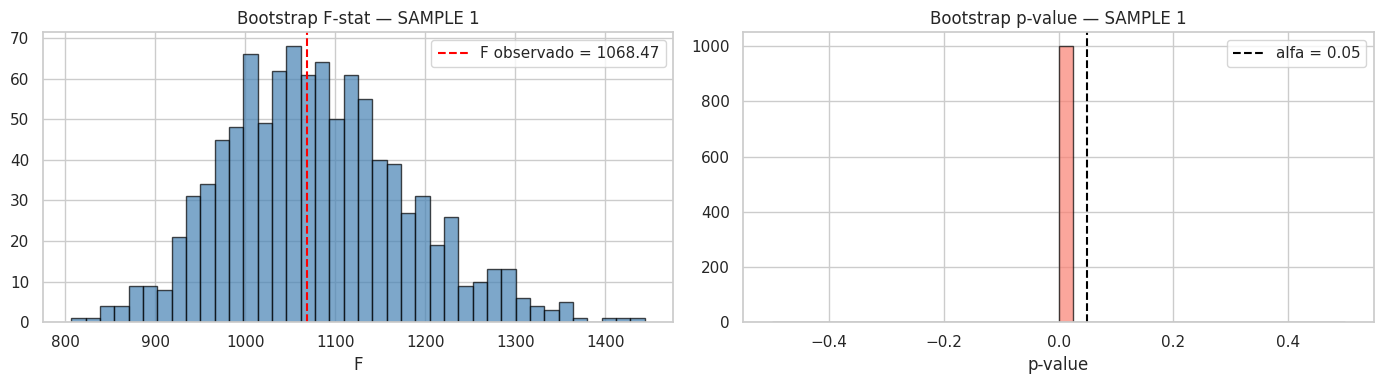

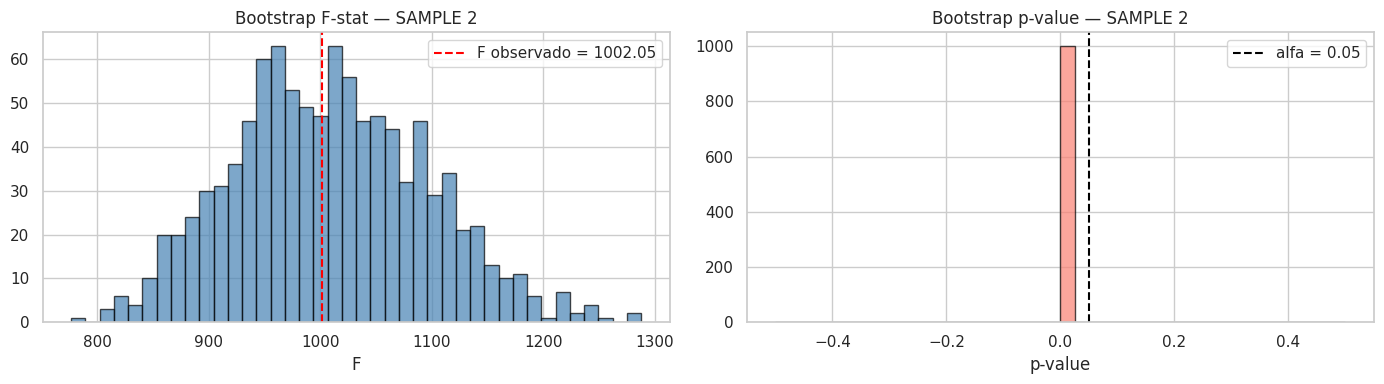

In [14]:
anova_s1 = anova_bootstrap_uma_amostra(sample1)
anova_s2 = anova_bootstrap_uma_amostra(sample2)
print(f"\nSAMPLE 1 — F observado: {anova_s1['f_obs']:.4f} | p observado: {anova_s1['p_obs']:.6g}")
print(f"SAMPLE 2 — F observado: {anova_s2['f_obs']:.4f} | p observado: {anova_s2['p_obs']:.6g}")
plotar_anova_bootstrap(anova_s1, 'SAMPLE 1')
plotar_anova_bootstrap(anova_s2, 'SAMPLE 2')


Nesta ETAPA, você deve fazer o **TESTE DE ANOVA (Bootstrap): p_value** sobre:

*   SAMPLE 1
*   SAMPLE 2
*   RESPONDER: Qual o BEST FIT ?

In [15]:
print(f"BEST FIT (SAMPLE 1): {anova_s1['best_fit']}")
print(f"BEST FIT (SAMPLE 2): {anova_s2['best_fit']}")


BEST FIT (SAMPLE 1): Diferenca significativa entre os grupos (H0 rejeitada em 100.0% das reamostragens)
BEST FIT (SAMPLE 2): Diferenca significativa entre os grupos (H0 rejeitada em 100.0% das reamostragens)


# **ETAPA 3: TESTE DE HIPÓTESES: Duas (2) amostras**

## **ETAPA 3.1: TESTE DE HIPÓTESES - Teste das Médias Amostrais: SAMPLE 1 e SAMPLE 2**

Nesta ETAPA, você deve fazer o **TESTE DE HIPÓTESES - Teste das Médias Amostrais:** a sua escolha, sobre:

*   SAMPLE 1 e SAMPLE 2

In [16]:
med = teste_medias_duas_amostras(sample1[TARGET], sample2[TARGET])



--- Teste t (Welch) : SAMPLE 1 vs SAMPLE 2 ---
  Media SAMPLE 1  : 593.3289
  Media SAMPLE 2  : 582.5599
  t = 0.7964 | p-value = 0.425866
  CONCLUSAO (alfa=5%): MEDIAS IGUAIS (nao rejeita H0)


### **ETAPA 3.1.1: TESTE DE ANOVA - Bootstrap: SAMPLE 1 e SAMPLE 2**

Nesta ETAPA, você deve fazer o **TESTE DE ANOVA (Bootstrap) sobre Teste das Médias Amostrais: p_value** sobre:

*   SAMPLE 1 e SAMPLE 2
*   RESPONDER: Qual o BEST FIT ?


--- Bootstrap diferenca de medias (B=2000) ---
  Media diferenca : +11.3628
  IC 95 %         : [-14.7914, +37.1640]
  p-value (vs 0)  : 0.37
  BEST FIT        : sem diferenca significativa


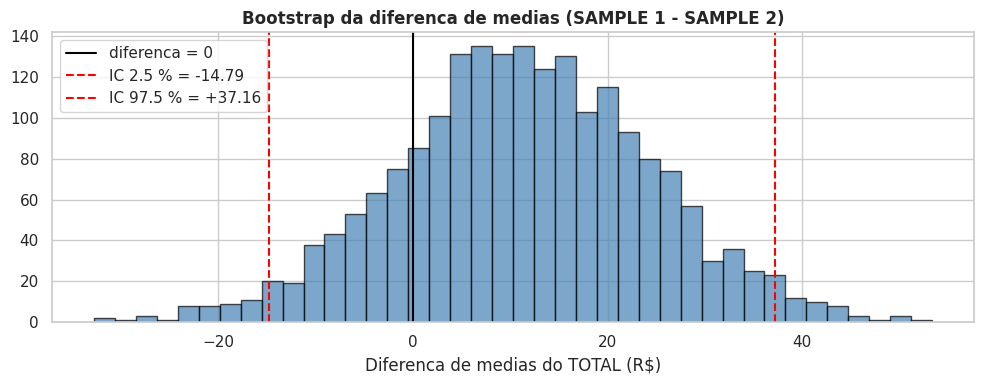


BEST FIT: NAO ha evidencia de diferenca entre as medias (p>0.05)


In [17]:
med_boot = bootstrap_diferenca_medias(sample1[TARGET], sample2[TARGET])

plt.figure(figsize=(10, 4))
plt.hist(med_boot['diffs'], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(0, color='black', linestyle='-', label='diferenca = 0')
plt.axvline(med_boot['ic'][0], color='red', linestyle='--', label=f"IC 2.5 % = {med_boot['ic'][0]:+.2f}")
plt.axvline(med_boot['ic'][1], color='red', linestyle='--', label=f"IC 97.5 % = {med_boot['ic'][1]:+.2f}")
plt.title('Bootstrap da diferenca de medias (SAMPLE 1 - SAMPLE 2)', fontweight='bold')
plt.xlabel(f'Diferenca de medias do {TARGET}')
plt.legend(); plt.tight_layout(); plt.show()

print(f"\nBEST FIT: " +
      ('diferenca significativa entre as medias (p<=0.05)' if med_boot['p'] <= 0.05
       else 'NAO ha evidencia de diferenca entre as medias (p>0.05)'))


## **ETAPA 3.2: TESTE DE HIPÓTESES - Testes de Correlação (mesma distribuição): SAMPLE 1 e SAMPLE 2**

Nesta ETAPA, você deve fazer o **TESTE DE HIPÓTESES - Testes de Correlação:** a sua escolha, sobre:

*   SAMPLE 1 e SAMPLE 2

In [18]:
ks = teste_ks_duas_amostras(sample1[TARGET], sample2[TARGET])



--- KS-test : SAMPLE 1 vs SAMPLE 2 ---
  KS = 0.0247 | p-value = 0.606398
  CONCLUSAO (alfa=5%): MESMA DISTRIBUICAO (nao rejeita H0)


### **ETAPA 3.2.1: TESTE DE ANOVA - Bootstrap: SAMPLE 1 e SAMPLE 2**

Nesta ETAPA, você deve fazer o **TESTE DE ANOVA (Bootstrap) sobre Testes de Correlação: p_value** sobre:

*   SAMPLE 1 e SAMPLE 2
*   RESPONDER: Qual o BEST FIT ?


--- Bootstrap KS (B=1000) ---
  KS medio                       : 0.0368
  p-value medio                  : 0.221313
  % reamostragens com p <= 0.05  : 17.9%
  BEST FIT                       : mesma distribuicao


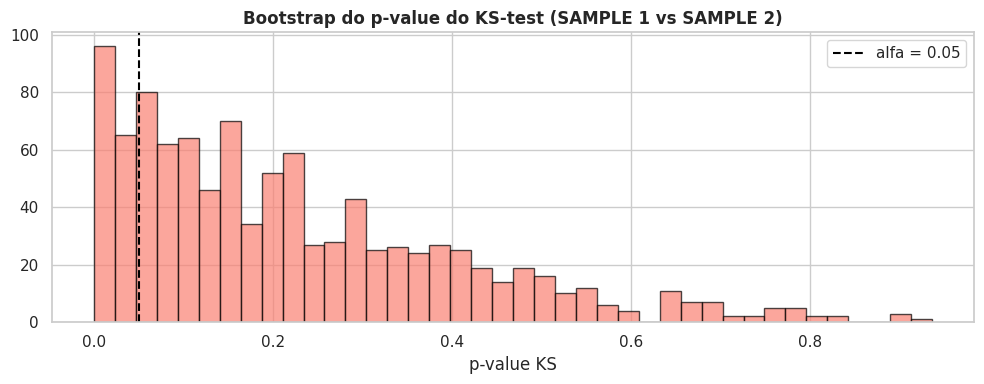


BEST FIT: mesma distribuicao mantida na maioria das reamostragens


In [19]:
ks_boot = bootstrap_ks(sample1[TARGET], sample2[TARGET])

plt.figure(figsize=(10, 4))
plt.hist(ks_boot['p_boot'], bins=40, color='salmon', edgecolor='black', alpha=0.7)
plt.axvline(0.05, color='black', linestyle='--', label='alfa = 0.05')
plt.title('Bootstrap do p-value do KS-test (SAMPLE 1 vs SAMPLE 2)', fontweight='bold')
plt.xlabel('p-value KS'); plt.legend(); plt.tight_layout(); plt.show()

print(f"\nBEST FIT: " +
      ('distribuicoes diferentes em > 95 % das reamostragens' if ks_boot['pct_rejeicao'] >= 95
       else 'mesma distribuicao mantida na maioria das reamostragens'))


## **ETAPA 3.3: TESTE DE HIPÓTESES - Testes de Independência sobre SAMPLE 1 e SAMPLE 2**

Nesta ETAPA, você deve fazer o **TESTE DE ANOVA (Bootstrap) sobre Testes de Independência: p_value** sobre:

*   SAMPLE 1 e SAMPLE 2
*   RESPONDER: Qual o BEST FIT ?

In [20]:
indep = teste_independencia_chi2(sample1, sample2, var1='REGIÃO', var2='TIPO DA CONTA')
print("\n--- Bootstrap Chi2 por amostra ---")
indep_boot_s1 = bootstrap_chi2(sample1, var1='REGIÃO', var2='TIPO DA CONTA')
indep_boot_s2 = bootstrap_chi2(sample2, var1='REGIÃO', var2='TIPO DA CONTA')

print(f"\nBEST FIT: SAMPLE 1 -> " +
      ('dependencia robusta (p<=0.05 em > 95 % do bootstrap)'
       if indep_boot_s1['pct_rejeicao'] >= 95 else
       'sem dependencia robusta'))
print(f"BEST FIT: SAMPLE 2 -> " +
      ('dependencia robusta (p<=0.05 em > 95 % do bootstrap)'
       if indep_boot_s2['pct_rejeicao'] >= 95 else
       'sem dependencia robusta'))



--- Chi-quadrado REGIÃO x TIPO DA CONTA : SAMPLE 1 ---
  Chi2 = 5.7723 | dof = 8 | p-value = 0.672722
  CONCLUSAO (alfa=5%): INDEPENDENTES (nao rejeita H0)

--- Chi-quadrado REGIÃO x TIPO DA CONTA : SAMPLE 2 ---
  Chi2 = 16.1313 | dof = 8 | p-value = 0.0405384
  CONCLUSAO (alfa=5%): DEPENDENTES (rejeita H0)

--- Bootstrap Chi2 por amostra ---
  Bootstrap Chi2 (REGIÃO x TIPO DA CONTA): todas as reamostragens degeneradas — sem resultado.
  Bootstrap Chi2 (REGIÃO x TIPO DA CONTA): todas as reamostragens degeneradas — sem resultado.

BEST FIT: SAMPLE 1 -> sem dependencia robusta
BEST FIT: SAMPLE 2 -> sem dependencia robusta


# **ETAPA 4: SIMULAÇÃO DE DADOS: Biblioteca RANDOM**

## **ETAPA 4.1: COLUNA RANDOM: TAMANHO IDEAL**

Nesta ETAPA, você deve simular uma variável, conforme sorteio, e criar uma **COLUNA RANDOM: TAMANHO IDEAL** que será inserida no seu SAMPLE 1 e SAMPLE 2.

In [21]:
sample1 = adicionar_coluna_random(sample1, seed=SEED)
sample2 = adicionar_coluna_random(sample2, seed=SEED + 1)
print('Coluna RANDOM adicionada em sample1 e sample2 (tamanho ideal).')
sample1[['RANDOM', TARGET]].head()


Coluna RANDOM adicionada em sample1 e sample2 (tamanho ideal).


,RANDOM,TOTAL (R$)
0,0.773956,460.339996
1,0.438878,609.119995
2,0.858598,483.380005
3,0.697368,541.150024
4,0.094177,453.570007


## **ETAPA 4.2: COLUNA RANDOM e TARGET Y: Análise de Correlação Linear**

In [22]:
corr1 = correlacao_random_target(sample1, 'SAMPLE 1')
corr2 = correlacao_random_target(sample2, 'SAMPLE 2')



--- Correlacao Pearson : SAMPLE 1 ---
  r = -0.0155 | p-value = 0.499894
  CONCLUSAO (alfa=5%): SEM correlacao significativa (nao rejeita H0)
  Observacao: como RANDOM e ruido uniforme independente do TARGET,
  o esperado e r ~ 0 e p > 0.05 — o teste valida que o pipeline
  nao acha correlacao espuria.

--- Correlacao Pearson : SAMPLE 2 ---
  r = +0.0187 | p-value = 0.415212
  CONCLUSAO (alfa=5%): SEM correlacao significativa (nao rejeita H0)
  Observacao: como RANDOM e ruido uniforme independente do TARGET,
  o esperado e r ~ 0 e p > 0.05 — o teste valida que o pipeline
  nao acha correlacao espuria.


## **ETAPA 4.3: COLUNA RANDOM e TARGET Y: Análise de Regressão Linear**


--- Regressao Linear : SAMPLE 1 ---
  intercepto (b0) : +604.7701
  coeficiente (b1): -22.7615
  R^2             : 0.000240
  p-value do slope: 0.499894


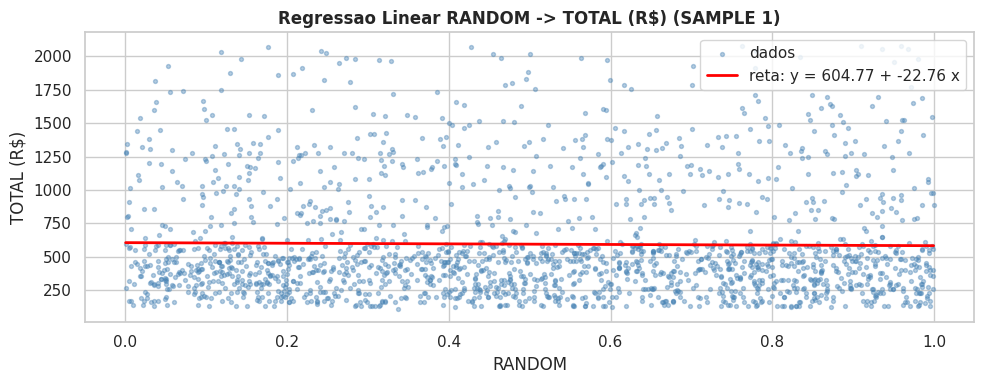


--- Regressao Linear : SAMPLE 2 ---
  intercepto (b0) : +569.3622
  coeficiente (b1): +26.1324
  R^2             : 0.000350
  p-value do slope: 0.415212


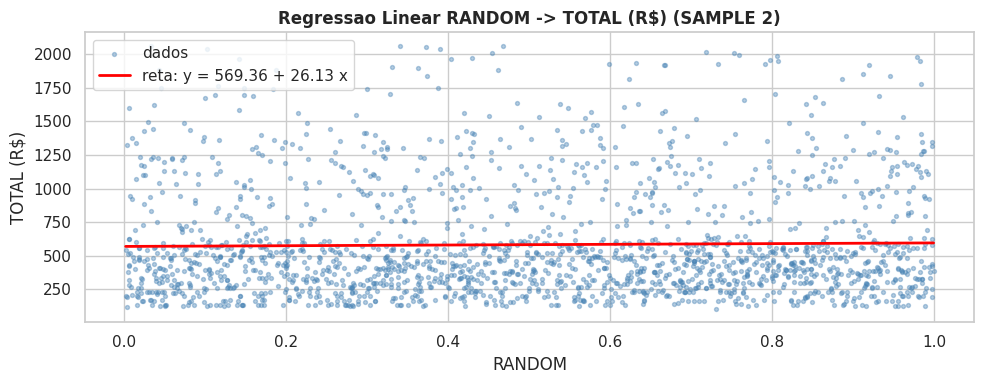

In [23]:
reg1 = regressao_random_target(sample1, 'SAMPLE 1')
reg2 = regressao_random_target(sample2, 'SAMPLE 2')


# **ETAPA 5: PIPELINE PYTHON (FACULTATIVO)**

Nesta etapa: PIPELINE, você deve elaborar um sequenciamento de comandos (pipeline) para automatizar em ordem as:
*   **ETAPA 0:** Pular essa etapa para os que já determinaram o **TAMANHO IDEAL da AMOSTRA**.
*  **ETAPA 1:**
*   **ETAPA 2:**
*   **ETAPA 3:**
*   **ETAPA 4:**


[PIPELINE] ETL...
Dataset limpo carregado: 1,009,840 linhas x 21 colunas.

[PIPELINE] ETAPA 1: amostras...
sample1: (1900, 21)  sample2: (1900, 21)

[PIPELINE] ETAPA 2: AD test + ANOVA bootstrap...

--- Anderson-Darling : SAMPLE 1 ---
  Estatistica A2     : 106.3869
  Niveis (%)         : [15.0, 10.0, 5.0, 2.5, 1.0]
  Valores criticos   : [0.561, 0.631, 0.752, 0.873, 1.035]
  Critico a 5 %      : 0.7520
  CONCLUSAO (alfa=5%): NAO Normal (rejeita H0)

--- Anderson-Darling : SAMPLE 2 ---
  Estatistica A2     : 94.6741
  Niveis (%)         : [15.0, 10.0, 5.0, 2.5, 1.0]
  Valores criticos   : [0.561, 0.631, 0.752, 0.873, 1.035]
  Critico a 5 %      : 0.7520
  CONCLUSAO (alfa=5%): NAO Normal (rejeita H0)

[PIPELINE] ETAPA 3: testes de duas amostras...

--- Teste t (Welch) : SAMPLE 1 vs SAMPLE 2 ---
  Media SAMPLE 1  : 593.3289
  Media SAMPLE 2  : 582.5599
  t = 0.7964 | p-value = 0.425866
  CONCLUSAO (alfa=5%): MEDIAS IGUAIS (nao rejeita H0)

--- Bootstrap diferenca de medias (B=2000) ---


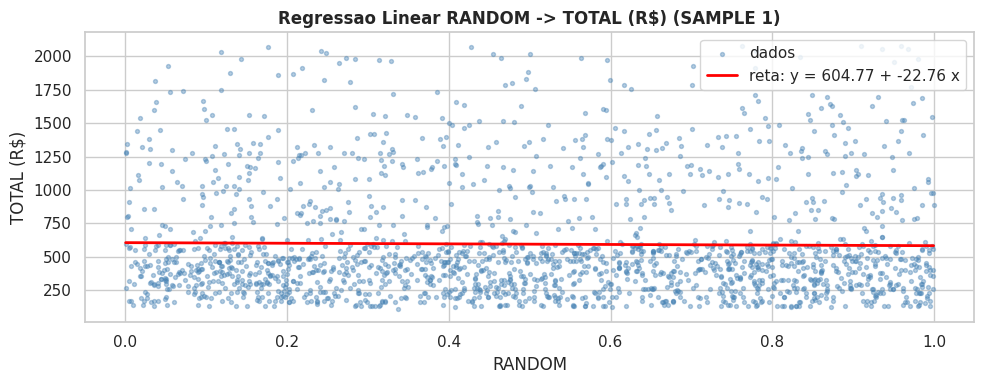


--- Regressao Linear : SAMPLE 2 ---
  intercepto (b0) : +569.3622
  coeficiente (b1): +26.1324
  R^2             : 0.000350
  p-value do slope: 0.415212


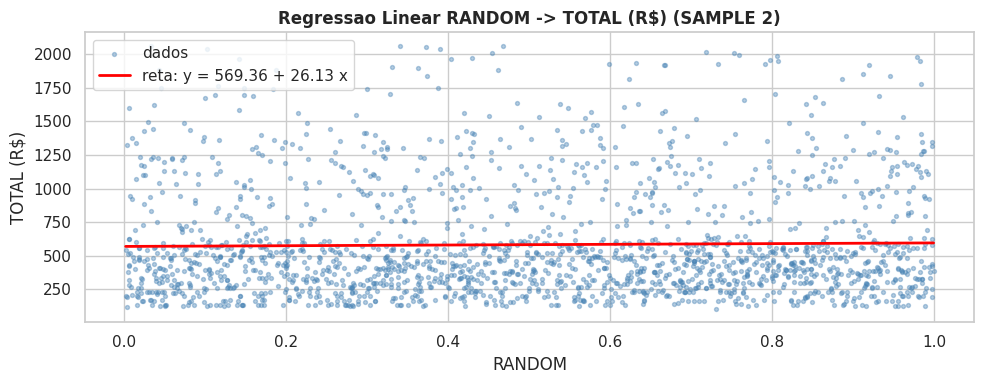


[PIPELINE] CONCLUIDO.

Chaves do resultado: ['sample1', 'sample2', 'ad', 'anova_boot', 'medias', 'medias_boot', 'ks', 'ks_boot', 'indep', 'indep_boot', 'corr', 'reg']


In [24]:
# pipeline completo (executa tudo do zero com semente fixa)
resultado_pipeline = pipeline_inferencia()
print('\nChaves do resultado:', list(resultado_pipeline.keys()))


# **OBRIGATÓRIO: Gerar este dois (2) PDF de PRODUTO:**

## **GERAR O PDF 1:**

PLANILHA DO RESULTADOS DA INFERÊNCIA ESTATÍSTICA: Link cloud no Blog:

In [25]:
# pode dar um LOAD desta planilha aqui:


## **GERAR O PDF 2:**

Gerar o PDF via NBCONVERT abaixo: